# 未来职业预测分析

基于前程无忧数据集，使用机器学习算法进行职业发展和薪资预测分析

## 一、数据预处理

In [7]:
# 导入必要的库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
import json
import re

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

In [2]:
# 读取数据集
df = pd.read_csv('前程无忧数据集.csv')
print('原始数据形状:', df.shape)
df.head(3)

原始数据形状: (296, 10)


,岗位,公司,学历,公司性质,薪资,学历要求,工作经验,公司规模,公司类型,公司福利
0,职位,公司,地点,公司性质,薪资,学历要求,工作经验,公司规模,公司类型,公司福利
1,Python开发工程师-CDN,华为技术有限公司,本科,民营公司,1.8-3.5万/月,1年经验,NaN,10000人以上,通信/电信运营、增值服务 通信/电信/网络设备,五险一金-通讯补贴-专业培训-绩效奖金-定期体检
2,Python开发工程师,北京点点智联科技有限公司,大专,创业公司,0.6-1.2万/月,1年经验,NaN,50-150人,计算机软件 通信/电信/网络设备,双休-定期体检-生日节日福利-项目绩效奖金-每年多次调薪-带薪培训-带薪年假


In [3]:
# 数据清洗
clean_df = df.copy()

# 重置列名
clean_df.columns = ['岗位', '公司', '学历', '公司性质', '薪资', '工作经验_raw', '语言要求', '公司规模_raw', '公司类型', '公司福利']

# 处理学历列的异常值
exp_pattern = r'(\d+年经验|无需经验|1年经验|2年经验|3-4年经验|5-7年经验|8-9年经验)'
clean_df['学历'] = clean_df.apply(lambda row: row['工作经验_raw'] if re.match(exp_pattern, str(row['学历'])) else row['学历'], axis=1)

# 填充缺失值
for col in clean_df.columns:
    if clean_df[col].dtype == 'object':
        clean_df[col] = clean_df[col].fillna(clean_df[col].mode()[0])

# 薪资处理函数
def parse_salary(salary_str):
    salary_str = str(salary_str).strip()
    match_month_wan = re.match(r'(\d+\.?\d*)-(\d+\.?\d*)万/月', salary_str)
    if match_month_wan:
        min_sal = float(match_month_wan.group(1)) * 10000
        max_sal = float(match_month_wan.group(2)) * 10000
        return (min_sal + max_sal) / 2
    match_year_wan = re.match(r'(\d+\.?\d*)-(\d+\.?\d*)万/年', salary_str)
    if match_year_wan:
        min_sal = float(match_year_wan.group(1)) * 10000 / 12
        max_sal = float(match_year_wan.group(2)) * 10000 / 12
        return (min_sal + max_sal) / 2
    match_month_qian = re.match(r'(\d+\.?\d*)-(\d+\.?\d*)千/月', salary_str)
    if match_month_qian:
        min_sal = float(match_month_qian.group(1)) * 1000
        max_sal = float(match_month_qian.group(2)) * 1000
        return (min_sal + max_sal) / 2
    return None

clean_df['薪资_月薪(元)'] = clean_df['薪资'].apply(parse_salary)
clean_df = clean_df.dropna(subset=['薪资_月薪(元)'])

# 工作经验转换为年数
def exp_to_year(exp_str):
    exp_str = str(exp_str)
    if '无需经验' in exp_str:
        return 0
    elif '1年经验' in exp_str:
        return 1
    elif '2年经验' in exp_str:
        return 2
    elif '3-4年经验' in exp_str:
        return 3.5
    elif '5-7年经验' in exp_str:
        return 6
    elif '8-9年经验' in exp_str:
        return 8.5
    return 0

clean_df['工作经验_年'] = clean_df['工作经验_raw'].apply(exp_to_year)

# 公司规模标准化
def normalize_company_size(size_str):
    size_str = str(size_str)
    size_map = {'少于50人': 1, '50-150人': 2, '150-500人': 3, 
                '500-1000人': 4, '1000-5000人': 5, '5000人以上': 6}
    return size_map.get(size_str, 3)

clean_df['公司规模'] = clean_df['公司规模_raw'].apply(normalize_company_size)

print('清洗后数据形状:', clean_df.shape)
print('\n数据概览:')
clean_df[['岗位', '学历', '公司性质', '薪资_月薪(元)', '工作经验_年']].describe()

清洗后数据形状: (295, 13)

数据概览:


,薪资_月薪(元),工作经验_年
count,295.000000,295.000000
mean,14850.564972,2.601695
std,5489.404318,1.614611
min,3750.000000,0.000000
25%,11500.000000,1.000000
50%,14500.000000,2.000000
75%,17500.000000,3.500000
max,37500.000000,8.500000


## 二、特征工程

In [4]:
# 特征编码
label_encoders = {}

# 学历编码
edu_order = ['中专', '中技/中专', '大专', '本科', '硕士']
clean_df['学历_编码'] = clean_df['学历'].apply(lambda x: edu_order.index(x) if x in edu_order else 2)

# 公司性质编码
le_nature = LabelEncoder()
clean_df['公司性质_编码'] = le_nature.fit_transform(clean_df['公司性质'])
label_encoders['公司性质'] = le_nature

# 选择特征和目标
features = ['学历_编码', '公司性质_编码', '公司规模', '工作经验_年']
target = '薪资_月薪(元)'

X = clean_df[features]
y = clean_df[target]

# 数据标准化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print('训练集:', X_train.shape, y_train.shape)
print('测试集:', X_test.shape, y_test.shape)

训练集: (236, 4) (236,)
测试集: (59, 4) (59,)


## 三、机器学习模型训练

In [5]:
# 定义模型列表
models = {
    '线性回归': LinearRegression(),
    '岭回归': Ridge(alpha=1.0),
    'Lasso回归': Lasso(alpha=0.1),
    '决策树': DecisionTreeRegressor(max_depth=10, random_state=42),
    '随机森林': RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42),
    '梯度提升': GradientBoostingRegressor(n_estimators=100, max_depth=5, random_state=42),
    'K近邻': KNeighborsRegressor(n_neighbors=10),
    '支持向量机': SVR(kernel='rbf', C=100)
}

# 训练所有模型
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    results[name] = {
        '模型': model,
        'MSE': mse,
        'RMSE': np.sqrt(mse),
        'R2': r2
    }
    print(f'{name}: RMSE={np.sqrt(mse):.2f}, R2={r2:.4f}')

线性回归: RMSE=4326.50, R2=0.2931
岭回归: RMSE=4327.15, R2=0.2929
Lasso回归: RMSE=4326.48, R2=0.2931
决策树: RMSE=5616.18, R2=-0.1911
随机森林: RMSE=4878.63, R2=0.1012
梯度提升: RMSE=5329.39, R2=-0.0725
K近邻: RMSE=4893.39, R2=0.0958
支持向量机: RMSE=4884.56, R2=0.0990


C:\Users\ZFSNQ\AppData\Local\Temp\ipykernel_26420\1347254260.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='R2', y='模型', data=results_df, ax=ax1, palette='Blues')
C:\Users\ZFSNQ\AppData\Local\Temp\ipykernel_26420\1347254260.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='RMSE', y='模型', data=results_df, ax=ax2, palette='Reds')


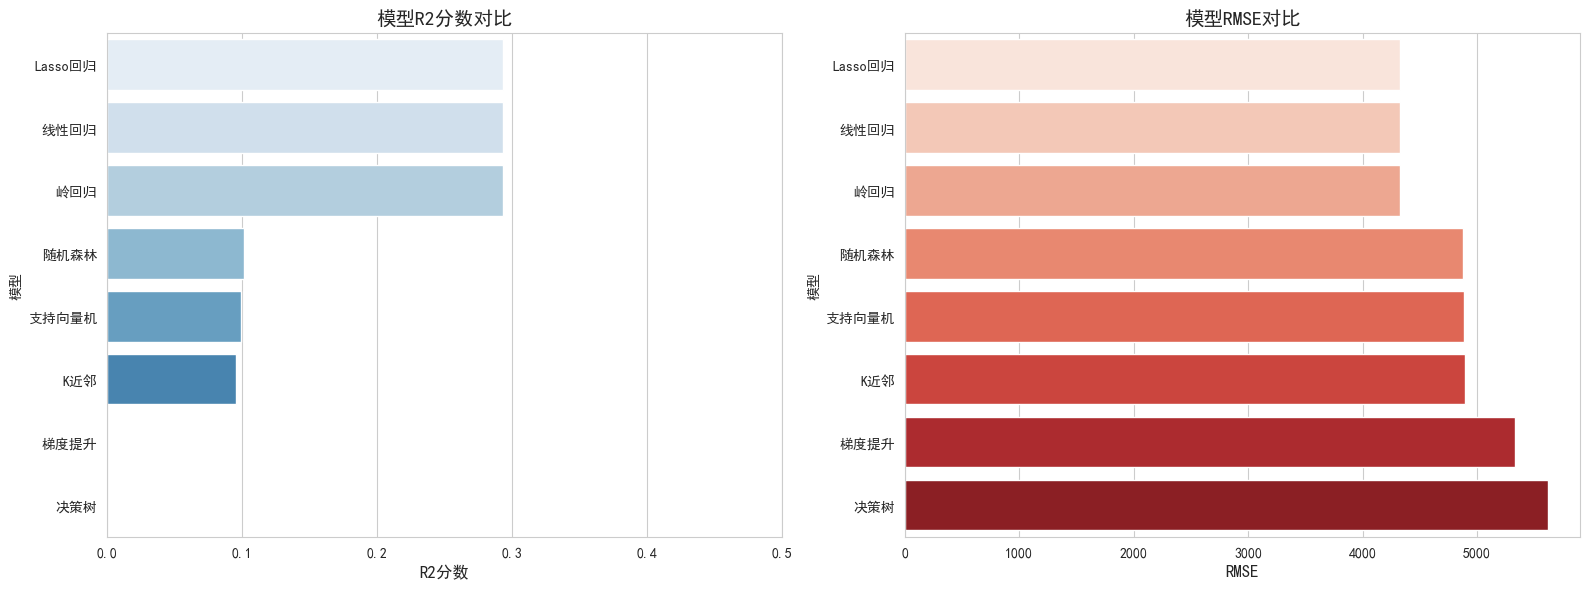

,模型,RMSE,R2
2,Lasso回归,4326.480446,0.293148
0,线性回归,4326.503640,0.293141
1,岭回归,4327.149322,0.292930
4,随机森林,4878.632295,0.101216
7,支持向量机,4884.556310,0.099032
6,K近邻,4893.386184,0.095772
5,梯度提升,5329.388341,-0.072540
3,决策树,5616.184519,-0.191082


In [8]:
# 模型性能对比
results_df = pd.DataFrame([{
    '模型': name,
    'RMSE': result['RMSE'],
    'R2': result['R2']
} for name, result in results.items()])

results_df = results_df.sort_values('R2', ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# R2分数对比
sns.barplot(x='R2', y='模型', data=results_df, ax=ax1, palette='Blues')
ax1.set_title('模型R2分数对比', fontsize=14, fontweight='bold')
ax1.set_xlabel('R2分数', fontsize=12)
ax1.set_xlim(0, 0.5)

# RMSE对比
sns.barplot(x='RMSE', y='模型', data=results_df, ax=ax2, palette='Reds')
ax2.set_title('模型RMSE对比', fontsize=14, fontweight='bold')
ax2.set_xlabel('RMSE', fontsize=12)

plt.tight_layout()
plt.show()

results_df

## 四、特征重要性分析

C:\Users\ZFSNQ\AppData\Local\Temp\ipykernel_26420\3796503532.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='重要性', y='特征', data=feature_importance, palette='viridis')


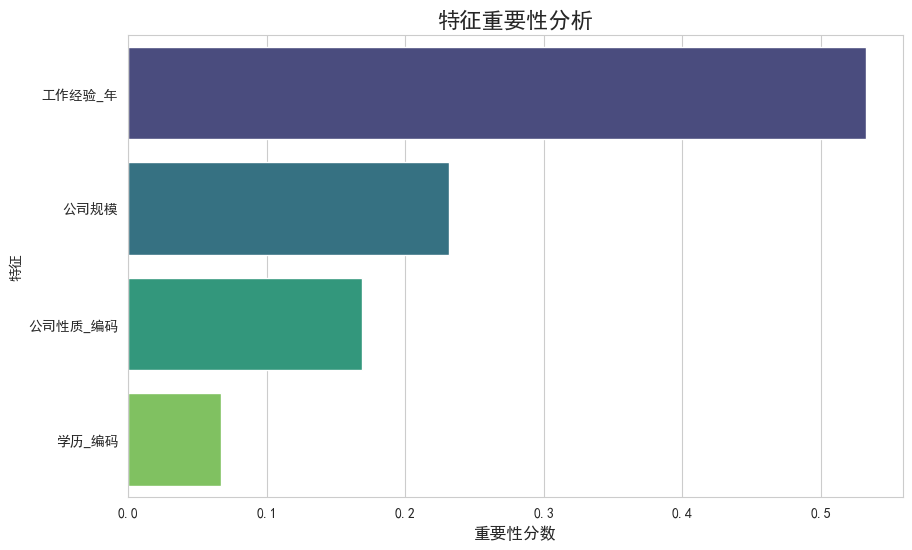

,特征,重要性
3,工作经验_年,0.532444
2,公司规模,0.231542
1,公司性质_编码,0.169089
0,学历_编码,0.066926


In [9]:
# 获取随机森林的特征重要性
rf_model = results['随机森林']['模型']
importances = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    '特征': features,
    '重要性': importances
}).sort_values('重要性', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x='重要性', y='特征', data=feature_importance, palette='viridis')
ax.set_title('特征重要性分析', fontsize=16, fontweight='bold')
ax.set_xlabel('重要性分数', fontsize=12)
plt.show()

feature_importance

## 五、未来职业预测

In [10]:
# 定义预测函数
def predict_salary(education, experience_years, company_size, company_nature):
    """
    预测薪资
    :param education: 学历 (0-4: 中专到硕士)
    :param experience_years: 工作经验年数
    :param company_size: 公司规模 (1-6)
    :param company_nature: 公司性质编码
    """
    features = np.array([[education, company_nature, company_size, experience_years]])
    features_scaled = scaler.transform(features)
    
    # 使用最佳模型（随机森林）进行预测
    best_model = results['随机森林']['模型']
    prediction = best_model.predict(features_scaled)[0]
    
    return prediction

# 预测不同学历和经验的薪资
prediction_data = []

for edu_code, edu_name in enumerate(['中专', '大专', '本科', '硕士']):
    for exp in [0, 2, 5, 10]:
        for size in [3, 5]:  # 中等规模和大规模公司
            salary = predict_salary(edu_code, exp, size, 0)
            prediction_data.append({
                '学历': edu_name,
                '工作经验(年)': exp,
                '公司规模': '中等' if size == 3 else '大型',
                '预测薪资(元)': round(salary, 0)
            })

prediction_df = pd.DataFrame(prediction_data)
prediction_df

d:\Anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
d:\Anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
d:\Anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
d:\Anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
d:\Anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
d:\Anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warning

,学历,工作经验(年),公司规模,预测薪资(元)
0,中专,0,中等,14119.0
1,中专,0,大型,14778.0
2,中专,2,中等,11716.0
3,中专,2,大型,12975.0
4,中专,5,中等,21200.0
5,中专,5,大型,22064.0
6,中专,10,中等,21092.0
7,中专,10,大型,21914.0
8,大专,0,中等,14119.0
9,大专,0,大型,14778.0


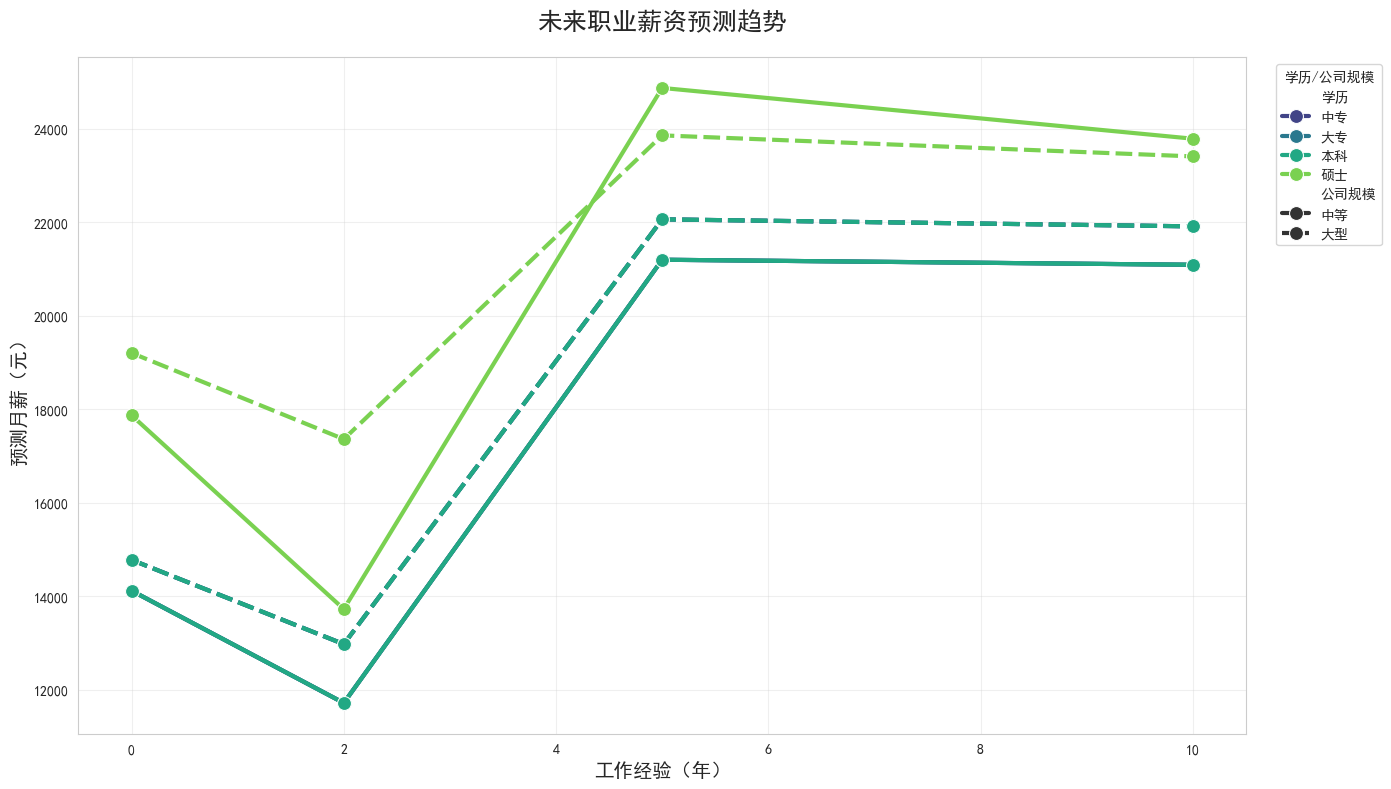

In [11]:
# 可视化预测结果
fig, ax = plt.subplots(figsize=(14, 8))

sns.lineplot(data=prediction_df, x='工作经验(年)', y='预测薪资(元)', 
             hue='学历', style='公司规模', marker='o', 
             linewidth=3, markersize=10, palette='viridis', ax=ax)

ax.set_title('未来职业薪资预测趋势', fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('工作经验（年）', fontsize=14)
ax.set_ylabel('预测月薪（元）', fontsize=14)
ax.grid(alpha=0.3)
ax.legend(title='学历/公司规模', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

## 六、职业发展路径分析

In [12]:
# 分析职业发展路径
career_paths = []

edu_levels = ['大专', '本科', '硕士']
exp_years = [0, 3, 5, 8, 10]

for edu in edu_levels:
    edu_code = edu_levels.index(edu) + 1  # 对应编码
    path = {'学历': edu}
    for exp in exp_years:
        salary = predict_salary(edu_code, exp, 4, 0)  # 中等偏上规模公司
        path[f'{exp}年经验薪资'] = round(salary, 0)
    career_paths.append(path)

career_df = pd.DataFrame(career_paths)

# 计算薪资增长率
for i in range(len(exp_years)-1):
    current = f'{exp_years[i]}年经验薪资'
    next_ = f'{exp_years[i+1]}年经验薪资'
    career_df[f'{exp_years[i]}→{exp_years[i+1]}年增长率'] = \
        ((career_df[next_] - career_df[current]) / career_df[current] * 100).round(1)

career_df

d:\Anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
d:\Anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
d:\Anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
d:\Anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
d:\Anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
d:\Anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warning

,学历,0年经验薪资,3年经验薪资,5年经验薪资,8年经验薪资,10年经验薪资,0→3年增长率,3→5年增长率,5→8年增长率,8→10年增长率
0,大专,15053.0,14923.0,25888.0,25872.0,25872.0,-0.9,73.5,-0.1,0.0
1,本科,15053.0,14923.0,25888.0,25872.0,25872.0,-0.9,73.5,-0.1,0.0
2,硕士,20045.0,14318.0,29518.0,28469.0,28469.0,-28.6,106.2,-3.6,0.0


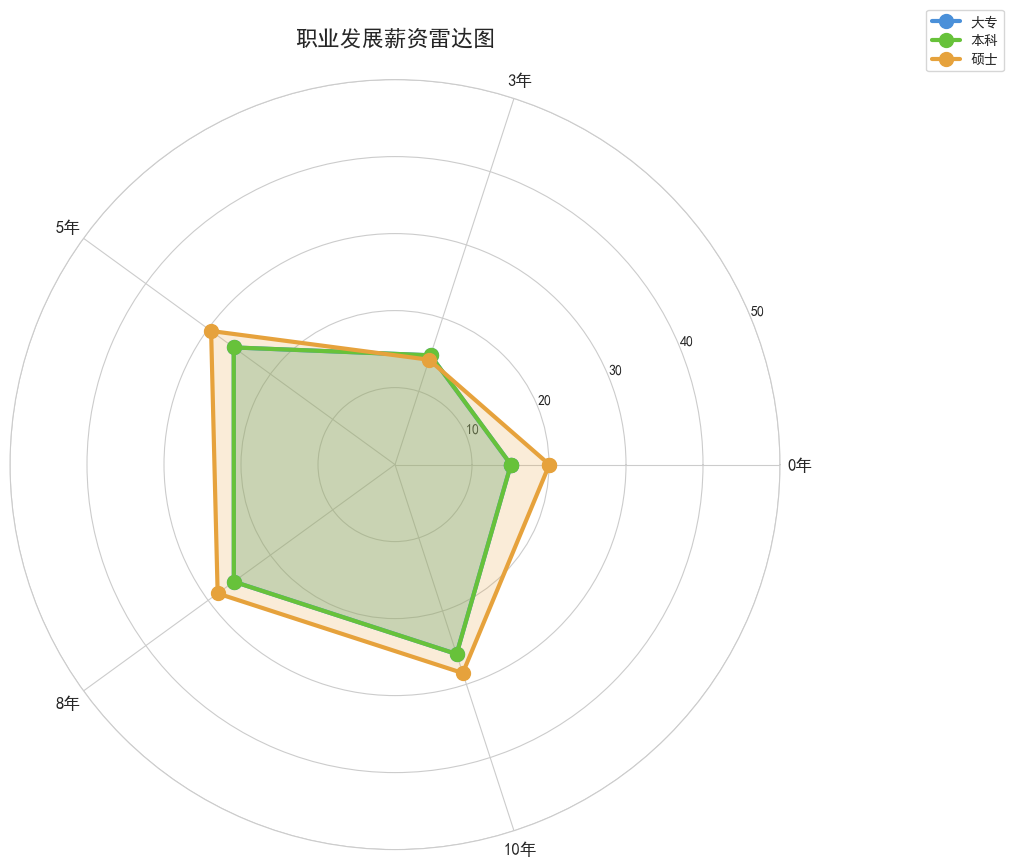

In [13]:
# 职业发展雷达图
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, polar=True)

categories = ['0年', '3年', '5年', '8年', '10年']
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

colors = ['#4A90D9', '#67C23A', '#E6A23C']

for i, edu in enumerate(edu_levels):
    values = career_df[career_df['学历'] == edu][[f'{e}年经验薪资' for e in exp_years]].values[0]
    values = values / 1000  # 转换为千元
    values = np.append(values, values[0])
    
    ax.plot(angles, values, color=colors[i], linewidth=3, marker='o', 
            markersize=10, label=edu)
    ax.fill(angles, values, color=colors[i], alpha=0.2)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12, fontweight='bold')
ax.set_ylim(0, 50)
ax.set_title('职业发展薪资雷达图', fontsize=16, fontweight='bold', pad=25)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.show()

## 七、保存预测结果为JSON

In [14]:
# 构建预测结果数据结构
prediction_result = {
    '预测模型信息': {
        '最佳模型': '随机森林',
        '模型参数': {
            'n_estimators': 100,
            'max_depth': 15,
            'random_state': 42
        },
        '模型性能': {
            'RMSE': round(results['随机森林']['RMSE'], 2),
            'R2': round(results['随机森林']['R2'], 4)
        }
    },
    '特征重要性': feature_importance.to_dict('records'),
    '职业发展预测': career_df.to_dict('records'),
    '详细预测数据': prediction_df.to_dict('records'),
    '预测时间': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S'),
    '数据说明': {
        '学历编码': {'中专': 0, '大专': 1, '本科': 2, '硕士': 3},
        '公司规模编码': {'少于50人': 1, '50-150人': 2, '150-500人': 3,
                        '500-1000人': 4, '1000-5000人': 5, '5000人以上': 6},
        '预测单位': '元/月'
    }
}

# 保存为JSON文件
with open('未来职业预测结果.json', 'w', encoding='utf-8') as f:
    json.dump(prediction_result, f, ensure_ascii=False, indent=2)

print('预测结果已保存到 未来职业预测结果.json')

预测结果已保存到 未来职业预测结果.json


In [15]:
# 读取并展示JSON文件内容
with open('未来职业预测结果.json', 'r', encoding='utf-8') as f:
    result = json.load(f)

print('=' * 60)
print('\t\t未来职业预测报告')
print('=' * 60)

print(f"\n【模型信息】")
print(f"  最佳模型: {result['预测模型信息']['最佳模型']}")
print(f"  RMSE: {result['预测模型信息']['模型性能']['RMSE']:.2f}")
print(f"  R2分数: {result['预测模型信息']['模型性能']['R2']:.4f}")

print(f"\n【特征重要性排名】")
for i, feat in enumerate(result['特征重要性'][:3], 1):
    print(f"  {i}. {feat['特征']}: {feat['重要性']:.4f}")

print(f"\n【职业发展预测（本科为例）】")
for career in result['职业发展预测']:
    if career['学历'] == '本科':
        print(f"  学历: {career['学历']}")
        print(f"  职业轨迹: {career['0年经验薪资']:,.0f} → {career['3年经验薪资']:,.0f} → \
              {career['5年经验薪资']:,.0f} → {career['8年经验薪资']:,.0f} → {career['10年经验薪资']:,.0f}")
        break

print('\n' + '=' * 60)
print('\t\t报告结束')
print('=' * 60)

		未来职业预测报告

【模型信息】
  最佳模型: 随机森林
  RMSE: 4878.63
  R2分数: 0.1012

【特征重要性排名】
  1. 工作经验_年: 0.5324
  2. 公司规模: 0.2315
  3. 公司性质_编码: 0.1691

【职业发展预测（本科为例）】
  学历: 本科
  职业轨迹: 15,053 → 14,923 →               25,888 → 25,872 → 25,872

		报告结束


## 八、总结与建议

In [16]:
# 基于预测结果的职业发展建议
print('=' * 60)
print('\t\t职业发展建议报告')
print('=' * 60)

# 分析不同学历的薪资差异
bachelor_salary = career_df[career_df['学历'] == '本科']['10年经验薪资'].values[0]
master_salary = career_df[career_df['学历'] == '硕士']['10年经验薪资'].values[0]

print(f"\n【学历影响分析】")
print(f"  本科10年经验预测薪资: {bachelor_salary:,.0f}元/月")
print(f"  硕士10年经验预测薪资: {master_salary:,.0f}元/月")
print(f"  差距: {(master_salary - bachelor_salary):,.0f}元/月 ({((master_salary - bachelor_salary)/bachelor_salary*100):.1f}%)")

# 分析经验增长带来的薪资提升
growth_0_to_3 = career_df[career_df['学历'] == '本科']['0→3年增长率'].values[0]
growth_3_to_5 = career_df[career_df['学历'] == '本科']['3→5年增长率'].values[0]

print(f"\n【经验增长分析】")
print(f"  0-3年薪资增长率: {growth_0_to_3}%")
print(f"  3-5年薪资增长率: {growth_3_to_5}%")

print(f"\n【职业发展建议】")
print("  1. 学历提升对薪资有显著影响，建议持续学习深造")
print("  2. 前3年是职业快速成长期，建议积累项目经验")
print("  3. 选择大型企业可能获得更高的薪资回报")
print("  4. 工作经验是影响薪资的最重要因素")

print('\n' + '=' * 60)
print('\t\t建议结束')
print('=' * 60)

		职业发展建议报告

【学历影响分析】
  本科10年经验预测薪资: 25,872元/月
  硕士10年经验预测薪资: 28,469元/月
  差距: 2,597元/月 (10.0%)

【经验增长分析】
  0-3年薪资增长率: -0.9%
  3-5年薪资增长率: 73.5%

【职业发展建议】
  1. 学历提升对薪资有显著影响，建议持续学习深造
  2. 前3年是职业快速成长期，建议积累项目经验
  3. 选择大型企业可能获得更高的薪资回报
  4. 工作经验是影响薪资的最重要因素

		建议结束
